[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oalnaseri/mobilcom_course/blob/main/11_frequency_reuse_interference_interactive.ipynb)

> **Run this notebook in Google Colab** — click the badge above (no local install needed).
> The setup cell below installs dependencies and enables interactive `ipywidgets` sliders in Colab.

---

# 🐝 Frequency Reuse, C/I and Sectorisation
### Interactive Teaching Notebook — DHBW Mobile Communications
---
Slide set 1 said *"neighbouring cells use different frequencies to avoid interference"*.
Slide set 2 asks the follow-up questions: **how many** different frequencies, **how far
apart** must the repeats be, and **what does it cost in capacity**?

This notebook draws the reuse pattern, computes the resulting **carrier-to-interference
ratio $C/I$**, and shows what **sectorisation** and **cell splitting** buy you — the two
measures the "reduce interference" and "increase capacity" slides list.

---

In [1]:
# ============================================================
#  COLAB / ENVIRONMENT SETUP  (safe to run locally too)
# ============================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # numpy + matplotlib ship with Colab; ensure ipywidgets is present
    !pip install -q ipywidgets

    # Required so ipywidgets sliders / interactive output render in Colab
    from google.colab import output
    output.enable_custom_widget_manager()

print("Environment ready.  IN_COLAB =", IN_COLAB)

Environment ready.  IN_COLAB = False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#f5f5f5'
print("Libraries loaded.")

Libraries loaded.


## 📚 Theory Reference

### Which cluster sizes are possible?
A hexagonal grid only tiles for
$$N=i^{2}+ij+j^{2},\qquad i,j\in\mathbb{N}_0
\;\Rightarrow\; N=1,3,4,7,9,12,13,16,19,21,\dots$$

### Reuse distance
$$\frac{D}{R}=\sqrt{3N}$$
$D$ = distance between two cells using the same frequency, $R$ = cell radius.

### Carrier-to-interference ratio
With a path-loss exponent $n$ and $N_I$ co-channel interferers in the first tier:
$$\frac{C}{I}\approx\frac{1}{N_I}\left(\frac{D}{R}\right)^{n}
=\frac{(3N)^{n/2}}{N_I}$$

| Antenna | first-tier interferers $N_I$ | gain over omni |
|---|---|---|
| omnidirectional | 6 | — |
| 3 sectors (120°) | 2 | $10\log_{10}3 = 4.8$ dB |
| 6 sectors (60°) | 1 | $10\log_{10}6 = 7.8$ dB |

GSM needs roughly $C/I \ge 9$ dB; planners normally design for **12 dB** to keep a margin.

### The price of a large cluster
With $S$ channels in total, each cell gets
$$\text{channels per cell}=\frac{S}{N}$$
so a bigger $N$ means better quality and **less capacity**. That is the central trade-off
of radio network planning.

### Cell splitting
Halving $R$ multiplies the number of cells per unit area by 4 — and leaves $C/I$
**unchanged**, because $C/I$ depends only on the *ratio* $D/R$. This is why "use small
cells" appears on both the interference slide and the capacity slide.

---

In [3]:
# ---------------------------------------------------------------
#  CORE
# ---------------------------------------------------------------
def cluster_sizes(max_N=32):
    """All valid hexagonal cluster sizes N = i^2 + i*j + j^2, with one (i, j)."""
    out = {}
    for i in range(0, 7):
        for j in range(0, 7):
            N = i*i + i*j + j*j
            if 0 < N <= max_N and N not in out:
                out[N] = (i, j)
    return dict(sorted(out.items()))

CLUSTERS = cluster_sizes()

def reuse_ratio(N):
    return np.sqrt(3.0*N)

def CI_dB(N, n=3.5, sectors=1):
    """Carrier-to-interference ratio [dB], first interference tier."""
    NI = {1: 6, 3: 2, 6: 1}[sectors]
    return 10*np.log10(reuse_ratio(N)**n / NI)

def hex_grid(radius=5):
    """Axial coordinates (q, r) of a hexagonal patch of cells."""
    cells = []
    for q in range(-radius, radius+1):
        for r in range(max(-radius, -q-radius), min(radius, -q+radius)+1):
            cells.append((q, r))
    return cells

def group_of(q, r, N):
    """Channel-group index of a cell, using the standard (i, j) reuse rule."""
    i, j = CLUSTERS[N]
    return (i*q + (i+j)*r) % N

def axial_to_xy(q, r, size=1.0):
    return size*np.sqrt(3)*(q + r/2.0), size*1.5*r

print("Valid cluster sizes:", list(CLUSTERS)[:12], "...")

Valid cluster sizes: [1, 3, 4, 7, 9, 12, 13, 16, 19, 21, 25, 27] ...


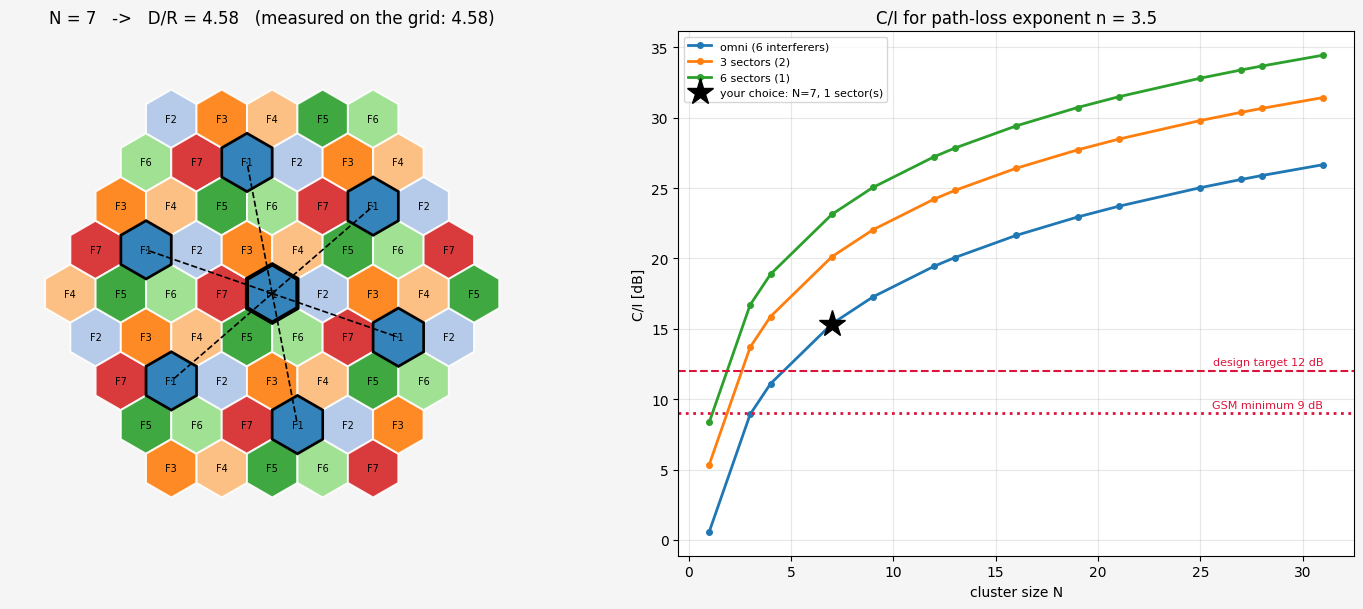

cluster size N        = 7
reuse ratio D/R       = 4.58
C/I                   = 15.4 dB   OK  (target 12 dB, GSM minimum 9 dB)
channels per cell     = 294/7 = 42.0

Cell splitting: halving R gives 4x the cells per km2 and leaves C/I at 15.4 dB (D/R is unchanged).


In [4]:
# ---------------------------------------------------------------
#  DRAW THE REUSE PATTERN
# ---------------------------------------------------------------
def plot_reuse(N=7, n=3.5, sectors=1, radius=4, S_channels=294):
    cells = hex_grid(radius)
    cmap  = plt.get_cmap('tab20')
    fig, ax = plt.subplots(1, 2, figsize=(15, 6.2),
                           gridspec_kw={'width_ratios': [1.15, 1]})

    # --- the honeycomb --------------------------------------------------
    for (q, r) in cells:
        x, y = axial_to_xy(q, r)
        g    = group_of(q, r, N)
        ax[0].add_patch(RegularPolygon((x, y), numVertices=6, radius=1.0,
                        orientation=0, facecolor=cmap(g % 20),
                        edgecolor='white', lw=1.4, alpha=.9))
        ax[0].text(x, y, f"F{g+1}", ha='center', va='center',
                   fontsize=7, color='black')
    # highlight one cell and its nearest co-channel neighbours
    x0, y0 = axial_to_xy(0, 0)
    ax[0].add_patch(RegularPolygon((x0, y0), numVertices=6, radius=1.0,
                    facecolor='none', edgecolor='black', lw=3))
    g0 = group_of(0, 0, N)
    co = [(q, r) for (q, r) in cells
          if group_of(q, r, N) == g0 and (q, r) != (0, 0)]
    d  = [np.hypot(*np.subtract(axial_to_xy(q, r), (x0, y0))) for q, r in co]
    if d:
        dmin = min(d)
        for (q, r), dd in zip(co, d):
            if dd < dmin*1.05:
                x, y = axial_to_xy(q, r)
                ax[0].plot([x0, x], [y0, y], 'k--', lw=1.2)
                ax[0].add_patch(RegularPolygon((x, y), numVertices=6, radius=1.0,
                                facecolor='none', edgecolor='black', lw=2))
        ax[0].set_title(f"N = {N}   ->   D/R = {reuse_ratio(N):.2f}"
                        f"   (measured on the grid: {dmin:.2f})")
    lim = (radius+1)*1.8
    ax[0].set_xlim(-lim, lim); ax[0].set_ylim(-lim, lim)
    ax[0].set_aspect('equal'); ax[0].axis('off')

    # --- C/I over the cluster size --------------------------------------
    Ns = np.array(list(CLUSTERS))
    for sec, col, lab in [(1, 'C0', 'omni (6 interferers)'),
                          (3, 'C1', '3 sectors (2)'),
                          (6, 'C2', '6 sectors (1)')]:
        ax[1].plot(Ns, [CI_dB(k, n, sec) for k in Ns], 'o-', color=col,
                   lw=2, ms=4, label=lab)
    ax[1].axhline(9, color='crimson', ls=':', lw=2)
    ax[1].text(Ns[-1], 9.4, 'GSM minimum 9 dB', color='crimson',
               ha='right', fontsize=8)
    ax[1].axhline(12, color='crimson', ls='--', lw=1.5)
    ax[1].text(Ns[-1], 12.4, 'design target 12 dB', color='crimson',
               ha='right', fontsize=8)
    ax[1].plot(N, CI_dB(N, n, sectors), '*', ms=20, color='black', zorder=5,
               label=f"your choice: N={N}, {sectors} sector(s)")
    ax[1].set_xlabel("cluster size N"); ax[1].set_ylabel("C/I [dB]")
    ax[1].set_title(f"C/I for path-loss exponent n = {n:.1f}")
    ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

    fig.tight_layout(); plt.show()

    ci = CI_dB(N, n, sectors)
    per_cell = S_channels/N
    print(f"cluster size N        = {N}")
    print(f"reuse ratio D/R       = {reuse_ratio(N):.2f}")
    print(f"C/I                   = {ci:.1f} dB   "
          f"{'OK' if ci >= 12 else ('marginal' if ci >= 9 else 'TOO LOW')}"
          f"  (target 12 dB, GSM minimum 9 dB)")
    print(f"channels per cell     = {S_channels}/{N} = {per_cell:.1f}")
    if sectors > 1:
        print(f"channels per sector   = {per_cell/sectors:.1f}"
              f"   ({sectors} sectors per site)")
    print(f"\nCell splitting: halving R gives 4x the cells per km2 "
          f"and leaves C/I at {ci:.1f} dB (D/R is unchanged).")

plot_reuse(N=7, n=3.5, sectors=1)

In [5]:
# ---------------------------------------------------------------
#  THE TRADE-OFF TABLE
# ---------------------------------------------------------------
def tradeoff_table(n=3.5, S=294):
    print(f"path-loss exponent n = {n},  {S} channels available in total\n")
    print(f"{'N':>3} {'D/R':>6} | {'C/I omni':>9} {'C/I 3-sec':>10} {'C/I 6-sec':>10}"
          f" | {'ch/cell':>8} {'verdict (omni)':>16}")
    print("-"*80)
    for N in list(CLUSTERS)[:10]:
        ci1, ci3, ci6 = (CI_dB(N, n, s) for s in (1, 3, 6))
        v = "good" if ci1 >= 12 else ("marginal" if ci1 >= 9 else "too much interf.")
        print(f"{N:>3} {reuse_ratio(N):>6.2f} | {ci1:>9.1f} {ci3:>10.1f} {ci6:>10.1f}"
              f" | {S/N:>8.1f} {v:>16}")

tradeoff_table()
print("\nRead the table as the planner does: go DOWN until C/I is acceptable,")
print("then stop -- every further row costs capacity for quality you do not need.")
print("Or: use sectorisation to reach the same C/I with a SMALLER N.")

path-loss exponent n = 3.5,  294 channels available in total

  N    D/R |  C/I omni  C/I 3-sec  C/I 6-sec |  ch/cell   verdict (omni)
--------------------------------------------------------------------------------
  1   1.73 |       0.6        5.3        8.3 |    294.0 too much interf.
  3   3.00 |       8.9       13.7       16.7 |     98.0 too much interf.
  4   3.46 |      11.1       15.9       18.9 |     73.5         marginal
  7   4.58 |      15.4       20.1       23.1 |     42.0             good
  9   5.20 |      17.3       22.0       25.0 |     32.7             good
 12   6.00 |      19.5       24.2       27.2 |     24.5             good
 13   6.24 |      20.1       24.8       27.8 |     22.6             good
 16   6.93 |      21.6       26.4       29.4 |     18.4             good
 19   7.55 |      22.9       27.7       30.7 |     15.5             good
 21   7.94 |      23.7       28.5       31.5 |     14.0             good

Read the table as the planner does: go DOWN until C/I

In [6]:
# ---------------------------------------------------------------
#  INTERACTIVE
# ---------------------------------------------------------------
style  = {'description_width': '205px'}
layout = widgets.Layout(width='560px')

dd_N   = widgets.Dropdown(options=list(CLUSTERS)[:10], value=7,
            description='cluster size N:', style=style, layout=layout)
sl_n   = widgets.FloatSlider(value=3.5, min=2.0, max=5.0, step=0.1,
            description='path-loss exponent n:', style=style, layout=layout)
tg_sec = widgets.ToggleButtons(options=[('omni', 1), ('3 sectors', 3), ('6 sectors', 6)],
            value=1, description='antenna:', style=style)
sl_S   = widgets.IntSlider(value=294, min=50, max=600, step=1,
            description='total channels S:', style=style, layout=layout)
sl_r   = widgets.IntSlider(value=4, min=2, max=6, step=1,
            description='grid size (display):', style=style, layout=layout)

def update(N, n, sec, S, r):
    plot_reuse(N, n, sec, r, S)

ui  = widgets.VBox([dd_N, sl_n, tg_sec, sl_S, sl_r])
out = widgets.interactive_output(update, {'N': dd_N, 'n': sl_n, 'sec': tg_sec,
                                          'S': sl_S, 'r': sl_r})
display(ui, out)

Output()

## 📝 Try this

1. **Find the classic GSM answer.** With $n = 3.5$ and omni antennas, walk down the cluster
   sizes until $C/I$ passes 12 dB. You should land on $N = 7$ — the reuse pattern in the
   picture on the very first content slide of slide set 1.
2. **Now switch to 3 sectors.** $C/I$ jumps by 4.8 dB, so a *smaller* cluster now meets
   the target — try $N = 4$ or even $N = 3$. Each cell keeps more channels, which is
   exactly why real GSM sites are three-sectored. This is "sectorisation" on the
   *reduce interference* slide paying off on the *increase capacity* slide.
3. **Change the environment.** Lower $n$ towards 2.5 (open, rural, little clutter).
   $C/I$ gets *worse* for the same $N$, because interference now travels as well as your
   wanted signal does. Clutter is not only an enemy.
4. **Cell splitting.** Note the last printed line: halving the cell radius quadruples
   capacity per km² and does **not** change $C/I$. It is the one measure that buys
   capacity without costing quality — it just costs money and sites.
5. **Count the co-channel neighbours** on the honeycomb: the black outlines mark the
   nearest cells reusing your frequency. Count them — you should find six, which is where
   the $1/6$ in the $C/I$ formula comes from.

## 📌 Summary

| Want | Do | Costs |
|---|---|---|
| better $C/I$ | larger $N$ | fewer channels per cell |
| better $C/I$ **free** | sectorisation | more antennas, more hardware per site |
| more capacity | smaller cells (splitting) | many more sites, more handovers |
| more capacity | more spectrum | very expensive, rarely available |

Radio network planning is choosing a point in this table — which is what
*"Steps in radio network planning"* is really about.